# Hello World Power Balance Model!

A first demo of using jax-ifyed CFSPOPCON functions to do time dependent simulation.

It's a simple single state power balance model evolving the stored energy dynamics.

It assumes ion density is given and makes the following assumption to get average ion/electron temperature and density:

    <p> = <n_e> <T_e> + <n_i> ion_to_electron_temp_ratio * <T_e>

Otherwise, it almost entirely uses CFSPOPCON functions to calculate the power balance:

1) Uses RADAS to calculate Zeff, dilution, impurity radiation
 2) CFSPOPCON analytic profiles
 3) Bremsstrahlung
 4) Synchrotron
 5) Alpha heating
 6) Ohmic heating


Okay, lets run a first simulation and see the state evolution!

In [10]:
%load_ext autoreload
%autoreload 2

from popsim.simulators.simple_power_balance.build_default import build_default
from popsim.simulators.simple_power_balance.simple_model import Params, Simulator
import jax
import jax.numpy as jnp
import pprint
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def module_to_dict(module):
    return {k: v for k, v in module.__dict__.items() if not k.startswith('_')}

# Build a default simulation
model, state, params = build_default()

print("State:")
pprint.pprint(module_to_dict(state))
print("Params:")

pprint.pprint(module_to_dict(params))

simulate = Simulator(model)
ts = jnp.linspace(0.0, 2.0, 100)
sol, derivs, debugs = simulate(ts, state, params)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
State:
{'stored_energy': 23.0}
Params:
{'P_aux_MW': 8,
 'areal_elongation': array(1.75),
 'average_ion_density': 27,
 'confinement_time_scalar': array(1.),
 'electron_density_peaking_offset': array(-0.1),
 'elongation_ratio_sep_to_areal': array(1.125),
 'fraction_of_external_power_coupled': array(0.9),
 'heavier_fuel_species_fraction': array(0.5),
 'impurity_concentrations': {<Impurity.Helium: 2>: 0.06,
                             <Impurity.Oxygen: 8>: 0.0031,
                             <Impurity.Tungsten: 74>: 1.5e-05},
 'inverse_aspect_ratio': array(0.3081),
 'ion_density_peaking_offset': array(-0.2),
 'ion_to_electron_temp_ratio': array(1.),
 'magnetic_field_on_axis': array(12.2),
 'major_radius': array(1.85),
 'normalized_inverse_temp_scale_length': array(2.5),
 'plasma_current': array(8700000.),
 'temperature_peaking': array(2.5),
 'triangularity_psi95': array(0.3),
 'triangularity_ratio_sep

Text(0.5, 1.0, 'Stored Energy vs. Time')

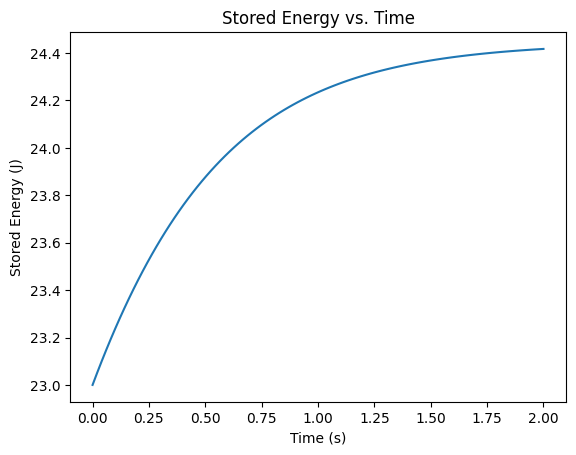

In [11]:
plt.plot(ts, sol.ys.stored_energy)
plt.xlabel("Time (s)")
plt.ylabel("Stored Energy (J)")
plt.title("Stored Energy vs. Time")

# Inspecting Debug Data
I also set the code up to output other debug data for us to look at, so lets see them

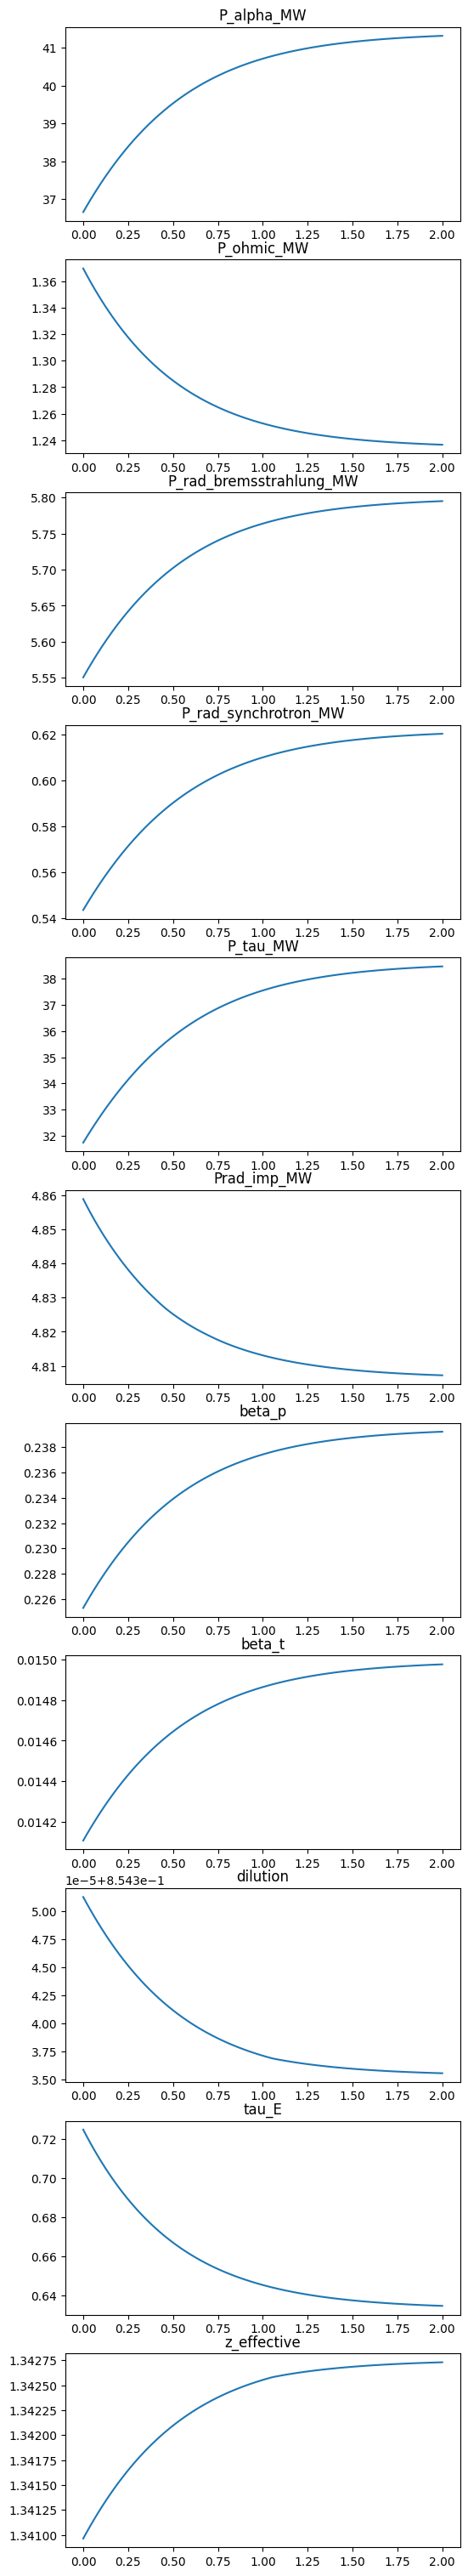

In [12]:
def plot_debug_dict(ts, debug_dict):
    n_vars = len(debug_dict.keys())
    f, axs = plt.subplots(n_vars, 1, figsize=(6, 3.5 * n_vars))
    for i, (k, v) in enumerate(debug_dict.items()):
        axs[i].plot(ts, v)
        axs[i].set_title(k)
    plt.show()

debug_vars = [
    "P_rad_bremsstrahlung_MW",
    "P_rad_synchrotron_MW",
    "Prad_imp_MW",
    "P_alpha_MW",
    "P_ohmic_MW",
    "P_tau_MW",
    "tau_E",
    "beta_p",
    "beta_t",
    "z_effective",
    "dilution",
]
plot_debug_dict(ts, {k: v for k, v in debugs.items() if k in debug_vars})

# Vectorized Simulation

Okay, now the real reason we are investing in Jax... lets run vectorized simulations across different tungsten impurity concentrations!

Of course, at this scale of running 10 simulations, Jax doesn't shine quite yet. But it'll scale.

This model seems to indicate that Tungsten is probably quite bad.

In [13]:
from popsim.enums import Impurity

def simulate_with_tungsten_concentration(tungsten_concentration):
    params_dict = module_to_dict(params)
    params_dict["impurity_concentrations"][Impurity.Tungsten] = tungsten_concentration
    params2 = Params(**params_dict)
    sol, derivs, debugs = simulate(ts, state, params2)
    return sol, derivs, debugs

n_sims = 10
tungsten_concentrations = jnp.logspace(-5, -4, n_sims)
sol, derivs, debugs = jax.vmap(simulate_with_tungsten_concentration)(tungsten_concentrations)
debugs = {k: v for k, v in debugs.items() if k in debug_vars}

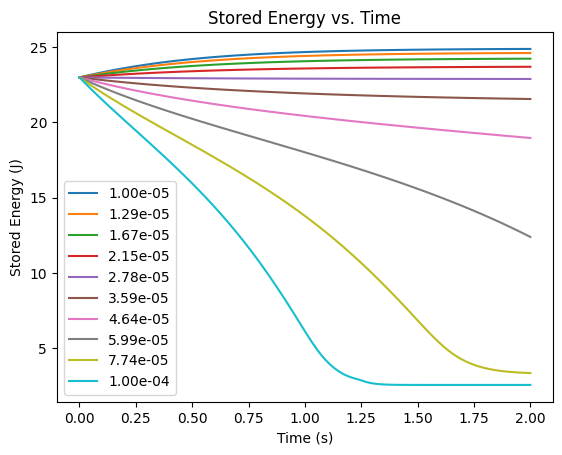

In [14]:
for i in range(n_sims):
    plt.plot(ts, sol.ys.stored_energy[i, :], label=f"{tungsten_concentrations[i]:.2e}")
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Stored Energy (J)")
plt.title("Stored Energy vs. Time")
plt.show()

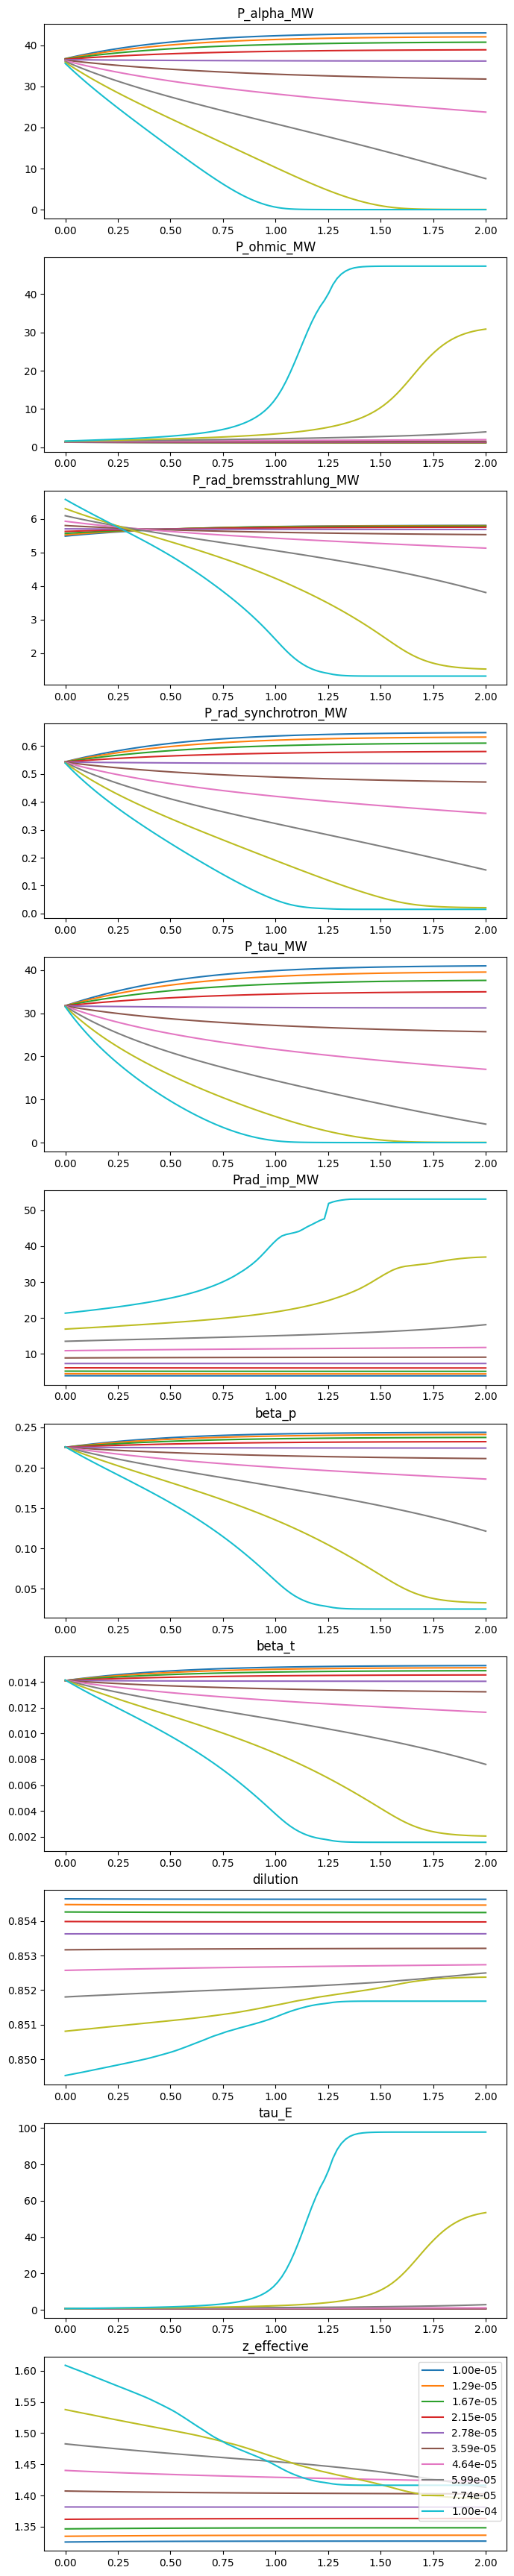

In [15]:
def plot_debug_dict(ts, debug_dict):
    n_vars = len(debug_dict.keys())
    f, axs = plt.subplots(n_vars, 1, figsize=(8, 4 * n_vars))
    for i, (k, v) in enumerate(debug_dict.items()):
        # print(k)
        # print(v.shape)
        for j in range(v.shape[0]):
            axs[i].plot(ts, v[j, :], label=f"{tungsten_concentrations[j]:.2e}")
            axs[i].set_title(k)
    plt.legend()
    plt.show()
plot_debug_dict(ts, debugs)